In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix     

#uso "from" per importare solo ciò che mi serve, invece che tutta la libreria. 

sns.set_theme(style="darkgrid")


In [2]:
# Ricarichiamo la sessione di Monza 2024
fastf1.Cache.enable_cache('../data/cache')
session = fastf1.get_session(2024, 'Monza', 'R')
session.load()

laps = session.laps    #creo variabile giri con tutti i giri della gara
laps_clean = laps[laps['IsAccurate'] == True].copy()  #creo variabile giri puliti della gara(IsAccurate) e ne creo sempre una copia 
laps_clean['LapTimeSeconds'] = laps_clean['LapTime'].dt.total_seconds()  #converto timedelta del laptime in secondi 

print(f"Dati caricati: {laps_clean.shape[0]} giri puliti")

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24', '18', '22']


Dati caricati: 927 giri puliti


In [3]:
# lavoro stint per stint come suggerito dall'EDA
# creo la variabile target: 1 se il tempo è sopra la mediana dello stint, 0 altrimenti
laps_model = laps_clean.copy()

laps_model['DegradoAlto'] = laps_model.groupby(      #creo variabile degrado alto e raggruppo i dati per stint e pilota.
    ['Driver', 'Stint'])['LapTimeSeconds'].transform(  
    lambda tempi: (tempi > tempi.median()).astype(int))  #lamba come funzione rapida senza nome inizializzata da transform. "tempi" è il parametro. 
    #astype(int) converte true/false in 1/0. 

    # Seleziono le features per il modello
features = ['TyreLife', 'LapNumber', 'Stint']
X = laps_model[features]  #variabili di input
y = laps_model['DegradoAlto'] #variabile target 

print(f"Feature selezionate: {features}")
print(f"Dimensioni X: {X.shape}")
print(f"Distribuzione target:\n{y.value_counts()}") #y.value_counts conta quanti 1 e quanti 0 ci sono nella variabile target

Feature selezionate: ['TyreLife', 'LapNumber', 'Stint']
Dimensioni X: (927, 3)
Distribuzione target:
DegradoAlto
0    479
1    448
Name: count, dtype: int64


In [ ]:
# Divid0 i dati in training set (80%) e test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1)  #test_size = 0.2 fa sì che il 20% dei dati sia nel test set e l'80% nel training set

print(f"Training set: {X_train.shape[0]} giri")
print(f"Test set: {X_test.shape[0]} giri")

Training set: 741 giri
Test set: 186 giri


In [6]:
modello = DecisionTreeClassifier(max_depth=4, random_state=1)  #4 indica la profodnità dell'albero decisionale, cioè 4 livelli di domande.
modello.fit(X_train, y_train) #addestro il modello 

print("Modello addestrato.")
print(f"Profondità dell'albero: {modello.get_depth()}")

Modello addestrato.
Profondità dell'albero: 4


In [7]:
# Usiamo il modello per fare previsioni sul test set
y_previsti = modello.predict(X_test)

# Report completo delle prestazioni
print("Report di classificazione:")
print(classification_report(y_test, y_previsti))

Report di classificazione:
              precision    recall  f1-score   support

           0       0.66      0.73      0.69       112
           1       0.51      0.42      0.46        74

    accuracy                           0.61       186
   macro avg       0.58      0.58      0.58       186
weighted avg       0.60      0.61      0.60       186



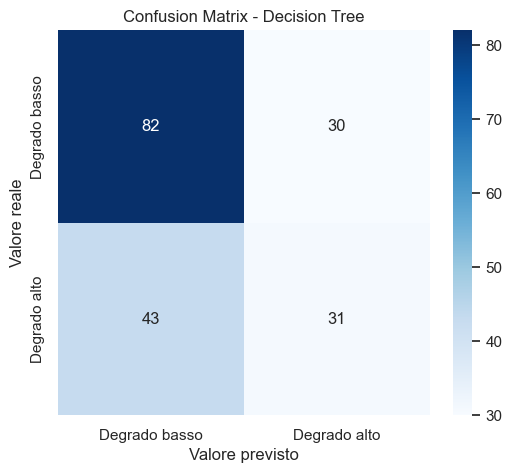

In [8]:
# confusion matrix
cm = confusion_matrix(y_test, y_previsti)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Degrado basso', 'Degrado alto'],
            yticklabels=['Degrado basso', 'Degrado alto'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Valore reale')
plt.xlabel('Valore previsto')
plt.show()